In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.preprocessing import load_data
from src.preprocessing import encode_features
from src.preprocessing import split_features
from src.preprocessing import scale_features

In [6]:
data = load_data("../data/raw/KDDTrain+.txt")
data = encode_features(data)
x,y = split_features(data)
x_scaled = scale_features(x)

In [7]:
from src.isolation_forest_model import train_isolation_forest

model = train_isolation_forest(x_scaled)

In [10]:
from src.isolation_forest_model import detect_anamolies

predictions = detect_anamolies(model,x_scaled)

In [11]:
import numpy as np

np.unique(predictions, return_counts = True)

(array([-1,  1]), array([ 12598, 113375]))

In [12]:
data['anamoly'] = predictions

In [13]:
data[data['anamoly'] == -1].head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,anamoly
25,507,1,60,9,437,14421,0,0,0,0,...,0.10,0.05,0.00,0.00,0.53,0.00,0.02,0.16,normal,-1
33,0,1,49,1,0,0,0,0,0,0,...,0.00,0.31,0.28,0.00,0.00,0.00,0.29,1.00,portsweep,-1
43,9052,2,44,9,146,105,0,0,0,0,...,0.01,0.66,0.99,0.00,0.00,0.00,0.00,0.00,normal,-1
62,0,1,49,1,0,0,0,0,0,0,...,0.00,0.84,0.00,0.00,0.07,0.00,0.62,1.00,satan,-1
89,315,2,44,9,146,105,0,0,0,0,...,0.02,0.54,0.78,0.00,0.00,0.00,0.00,0.00,normal,-1
102,0,1,24,1,0,0,0,0,0,0,...,1.00,0.00,1.00,0.15,0.00,0.00,1.00,0.68,normal,-1
104,0,2,49,9,28,0,0,3,0,0,...,0.71,0.29,0.71,0.00,0.09,0.00,0.20,0.00,teardrop,-1
109,0,1,24,1,0,0,0,0,0,0,...,1.00,0.00,0.04,0.10,0.00,0.00,1.00,0.96,normal,-1
111,0,1,54,9,2089,335,0,0,0,0,...,0.60,0.03,0.00,0.00,0.01,0.02,0.00,0.01,normal,-1
112,0,1,24,1,0,0,0,0,0,0,...,1.00,0.00,0.17,0.21,0.00,0.00,1.00,0.88,normal,-1


In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x_scaled)

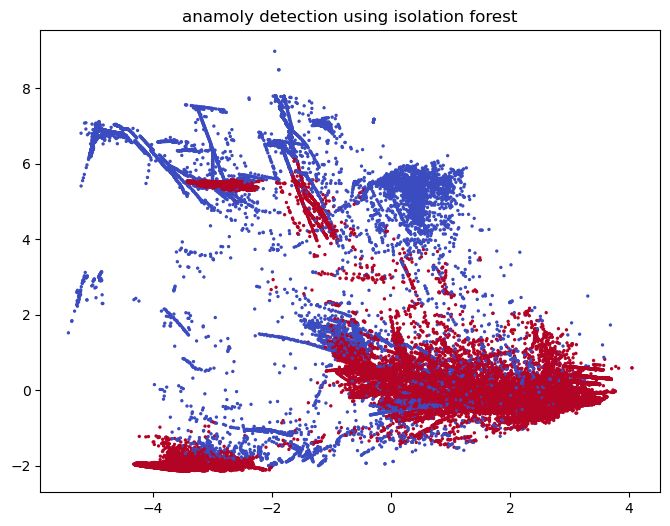

In [16]:
plt.figure(figsize = (8,6))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c = predictions,
    cmap = "coolwarm",
    s=2
)

plt.title("anamoly detection using isolation forest")
plt.show()

In [17]:
import joblib

joblib.dump(model, "../results/isolation_forest_model.pkl")

['../results/isolation_forest_model.pkl']